In [1]:
import numpy as np
from matplotlib.pyplot import subplots

from stimuli import (
    generate_start_position,
    generate_vertices,
    calculate_contour_positions,
    generate_background_elements,
    generate_gabor_patch,
)

## Set Starting Gabor and Contour Variables

In [2]:
# Set random seed
seed = 0
rng = np.random.default_rng(seed)

# Declare Image
image_size = 512
positive_stimulus = np.zeros((image_size, image_size))
negative_stimulus = np.zeros((image_size, image_size))

# Set Gabor Patch Variables
period = 8
phase = 0
sigma = 4

# Set Contour Line Variables
step_length = 32
beta = np.deg2rad(30)
jitter_max = np.deg2rad(10)
n_patches = 12
start_pos, theta0 = generate_start_position(beta, rng)

# Generate Vertices
vertices, pos_contour_angles, occupied_cells = generate_vertices(start_pos, step_length, theta0, beta, jitter_max, n_patches, rng)

# Get Positive Contour and Background Positions
pos_contour_positions = calculate_contour_positions(vertices)
pos_background_positions, pos_background_angles = generate_background_elements(occupied_cells, rng, image_size)

# Get Negative Contour and Background Positions
neg_background_positions, neg_background_angles = generate_background_elements(set(), rng, image_size)

## Generate Contour Stimulus

In [3]:
# Add Contour Gabors
for i in range(n_patches):
    x_position, y_position = pos_contour_positions[i]
    patch = generate_gabor_patch(period, phase, sigma, pos_contour_angles[i], x_position, y_position, image_size)
    positive_stimulus += patch

# Add Background Gabors
for i in range(len(pos_background_positions)):
    x_position, y_position = pos_background_positions[i]
    patch = generate_gabor_patch(period, phase, sigma, pos_background_angles[i], x_position, y_position, image_size)
    positive_stimulus += patch

## Generate No Contour Stimulus

In [4]:
for i in range(len(neg_background_positions)):
    x_position, y_position = neg_background_positions[i]
    patch = generate_gabor_patch(period, phase, sigma, neg_background_angles[i], x_position, y_position, image_size)
    negative_stimulus += patch

## Plot

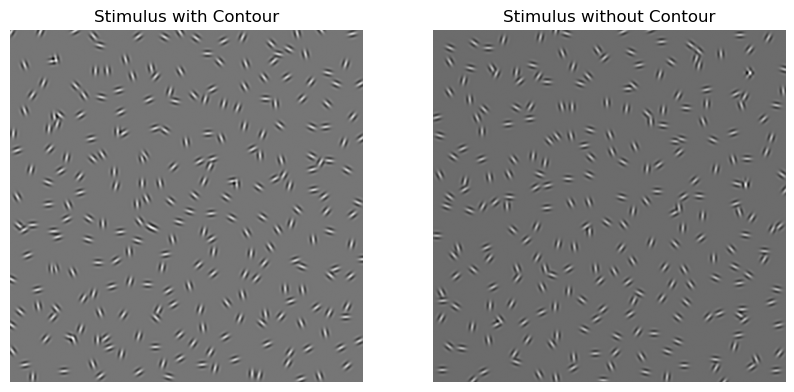

In [5]:
# Convert image-centered vertex coordinates to pixel coordinates
vertices_plot = vertices + image_size // 2

fig, ax = subplots(ncols=2, nrows=1, figsize=(10, 10))
ax[0].imshow(positive_stimulus, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Stimulus with Contour')

ax[1].imshow(negative_stimulus, cmap='gray')
ax[1].axis('off')
ax[1].set_title('Stimulus without Contour')

fig.savefig('Example_Stimulus.png', dpi=600, bbox_inches='tight')